In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Load data for left panels (graphical abstract dataset)
results_abstract = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250711-folde-testset-wCL',
    []
)
mutant_df_abstract, round_metrics_df_abstract = convert_compaign_result_collection_to_df(results_abstract)

# Load data for right panels (multimutant dataset)
results_multimutant = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250721-spg1-olson-2014-RERUN',
    []
)
mutant_df_multi, round_metrics_df_multi = convert_compaign_result_collection_to_df(results_multimutant)
round_metrics_df_multi['dms_shortname'] = round_metrics_df_multi.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'PTEN_HUMAN_Mighell_2018', 'ADRB2_HUMAN_Jones_2020', 'P53_HUMAN_Giacomelli_2018_Null_Nutlin', 'LGK_LIPST_Klesmith_2015', 'AMIE_PSEAE_Wrenbeck_2017', 'MK01_HUMAN_Brenan_2016', 'CAS9_STRP1_Spencer_2017_positive', 'P53_HUMAN_Giacomelli_2018_WT_Nutlin', 'KKA2_KLEPN_Melnikov_2014', 'PPARG_HUMAN_Majithia_2016', 'S22A1_HUMAN_Yee_2023_activity', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'SC6A4_HUMAN_Young_2021', 'MET_HUMAN_Estevam_2023', 'MTHR_HUMAN_Weile_2021'}
Loading results for DMSs: {'SPG1_STRSG_Olson_2014'}


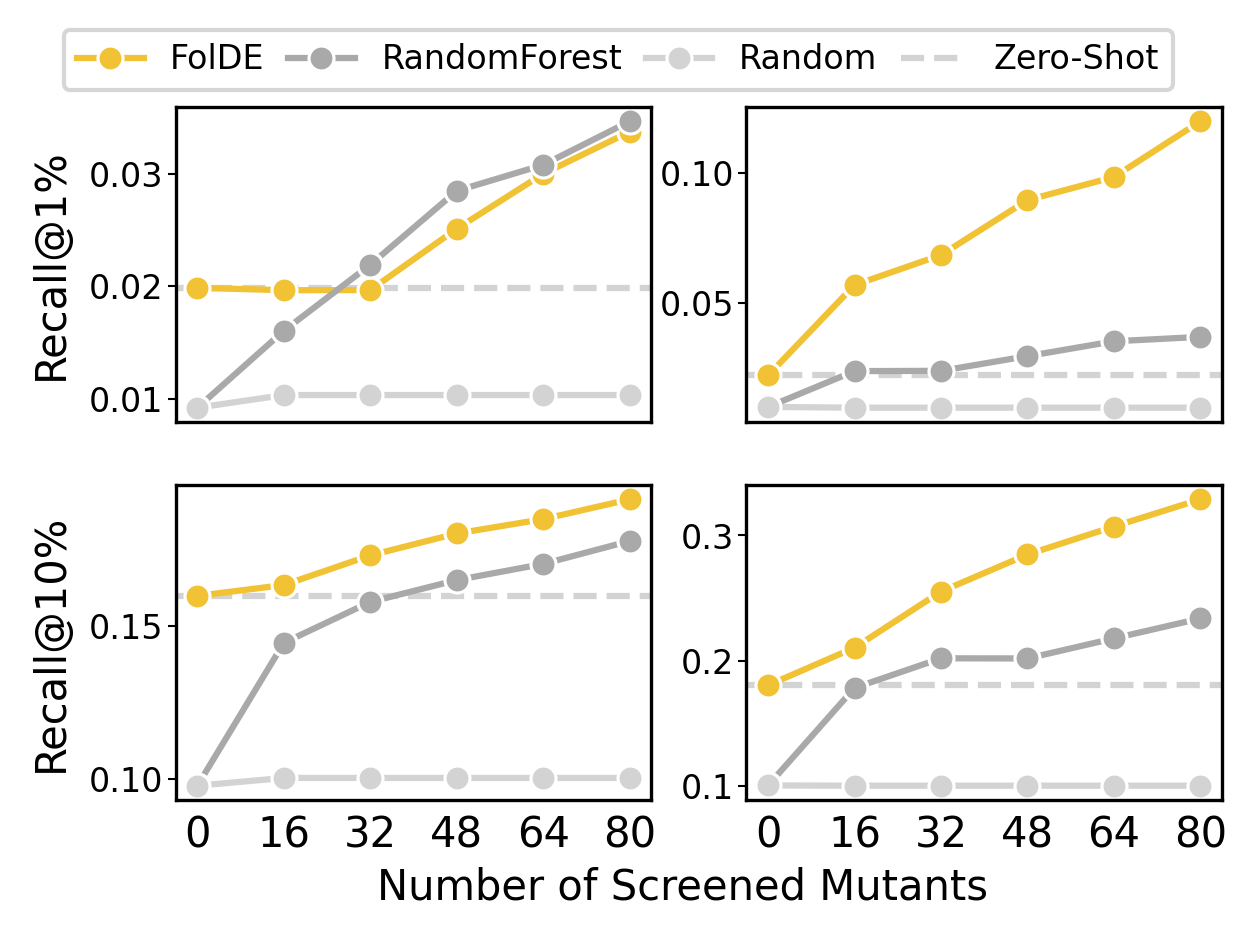

In [32]:
# Create the 2x2 combined figure
fig, ((ax_tl, ax_tr), (ax_bl, ax_br)) = plt.subplots(2, 2, figsize=(4.5, 3.0), dpi=300, sharex='col')

# === LEFT PANELS: Graphical Abstract Dataset ===
plot_df_abstract = round_metrics_df_abstract.copy()
CONFIGS_TO_PLOT = ['FolDE', 'RandomForest', 'Random']

plot_df_abstract['Screened mutants'] = plot_df_abstract.round_num * 16 - 16
plot_df_abstract['config_name'] = plot_df_abstract.config_name.apply(lambda x: {
    'FolDE-base': 'FolDE',
    'FolDE-random': 'Random',
    'FolDE-Random-RandomForestCtrl': 'RandomForest'
}.get(x, x))

# Top left: Recall 1%
ax_tl.axhline(plot_df_abstract[
        (plot_df_abstract.config_name == 'FolDE') &
        (plot_df_abstract.round_num == 1)
    ]['held_out_1pct_recall'].mean(),
    color='lightgrey',
    linestyle='--',
    label='Zero-Shot')

sns.lineplot(
    ax=ax_tl,
    data=plot_df_abstract[(plot_df_abstract.round_num <= 6) & (
        plot_df_abstract.config_name.isin(CONFIGS_TO_PLOT))],
    y='held_out_1pct_recall',
    x='Screened mutants',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=CONFIGS_TO_PLOT,
    palette={'FolDE': '#F1C233', 'RandomForest': 'darkgrey', 'Random': 'lightgrey'}
)

ax_tl.set_ylabel('Recall@1%')
ax_tl.set_xlabel('')
ax_tl.set_xticks([0, 16, 32, 48, 64, 80])
# ax_tl.set_title('A', fontsize=14, fontweight='bold', loc='left')

handles, labels = ax_tl.get_legend_handles_labels()
order = list(range(1, len(handles))) + [0]
ax_tl.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc='center',
    bbox_to_anchor=(0.93, 1.15),
    fontsize=8,
    ncol=4,
    columnspacing=0.7  # Add smaller column spacing
)
# ax_tl.get_legend().remove()

# Bottom left: Recall 10%
ax_bl.axhline(plot_df_abstract[
        (plot_df_abstract.config_name == 'FolDE') &
        (plot_df_abstract.round_num == 1)
    ]['held_out_10pct_recall'].mean(),
    color='lightgrey',
    linestyle='--',
    label='Zero-Shot')

sns.lineplot(
    ax=ax_bl,
    data=plot_df_abstract[(plot_df_abstract.round_num <= 6) & (
        plot_df_abstract.config_name.isin(CONFIGS_TO_PLOT))],
    y='held_out_10pct_recall',
    x='Screened mutants',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=CONFIGS_TO_PLOT,
    palette={'FolDE': '#F1C233', 'RandomForest': 'darkgrey', 'Random': 'lightgrey'}
)

ax_bl.set_ylabel('Recall@10%')
ax_bl.set_xticks([0, 16, 32, 48, 64, 80])
# ax_bl.set_title('C', fontsize=14, fontweight='bold', loc='left')

# Add legend to bottom left
# handles, labels = ax_bl.get_legend_handles_labels()
# order = list(range(1, len(handles))) + [0]
# ax_bl.legend(
#     [handles[i] for i in order],
#     [labels[i] for i in order],
#     loc='right',
#     bbox_to_anchor=(1.1, 0.3),
#     fontsize=8
# )
ax_bl.get_legend().remove()
ax_bl.set_xlabel('')

# === RIGHT PANELS: Multimutant Dataset ===
CONFIGS_MULTI = [
    ('FolDE-1-vs-rest', 'FolDE (1-vs-2)'),
    ('RandomToRandomForest-1-vs-rest', 'RandomForest (1-vs-2)'),
    ('Random-1-vs-rest', 'Random'),
]

def get_color(config_name):
    if config_name == 'FolDE (1-vs-2)':
        return '#F1C233'
    elif config_name.startswith('RandomForest'):
        return 'darkgrey'
    else:
        return 'lightgrey'

plot_df_multi = round_metrics_df_multi.copy()
plot_df_multi['config_name'] = plot_df_multi.config_name.apply(lambda x: dict(CONFIGS_MULTI).get(x, x))
plot_df_multi['Screened mutants'] = plot_df_multi.round_num * 16 - 16

ax_tr.axhline(plot_df_multi[
        (plot_df_multi.config_name == 'FolDE (1-vs-2)') &
        (plot_df_multi.round_num == 1)
    ]['held_out_1pct_recall'].mean(),
    color='lightgrey',
    linestyle='--',
    label='Zero-Shot')

# Top right: Recall 1%
sns.lineplot(
    ax=ax_tr,
    data=plot_df_multi[plot_df_multi.config_name.isin([c[1] for c in CONFIGS_MULTI])],
    y='held_out_1pct_recall',
    x='Screened mutants',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=[c[1] for c in CONFIGS_MULTI],
    palette={c[1]: get_color(c[1]) for c in CONFIGS_MULTI}
)

ax_tr.set_ylabel('')
ax_tr.set_xlabel('')
# ax_tr.set_title('B', fontsize=14, fontweight='bold', loc='left')
ax_tr.get_legend().remove()

# Bottom right: Recall 10%
ax_br.axhline(plot_df_multi[
        (plot_df_multi.config_name == 'FolDE (1-vs-2)') &
        (plot_df_multi.round_num == 1)
    ]['held_out_10pct_recall'].mean(),
    color='lightgrey',
    linestyle='--',
    label='Zero-Shot')
sns.lineplot(
    ax=ax_br,
    data=plot_df_multi[plot_df_multi.config_name.isin([c[1] for c in CONFIGS_MULTI])],
    y='held_out_10pct_recall',
    x='Screened mutants',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=[c[1] for c in CONFIGS_MULTI],
    palette={c[1]: get_color(c[1]) for c in CONFIGS_MULTI}
)

ax_br.set_ylabel('')
ax_br.set_xticks([0, 16, 32, 48, 64, 80])
# ax_br.set_xlabel('Number of Screened mutants')
# ax_br.set_title('D', fontsize=14, fontweight='bold', loc='left')
# handles, labels = ax_bl.get_legend_handles_labels()
# order = list(range(1, len(handles))) + [0]
# ax_br.legend(
#     [handles[i] for i in order],
#     [labels[i] for i in order],
#     # title='Workflow',
#     loc='right',
#     bbox_to_anchor=(1.0, 0.3),
#     fontsize=8
# )
ax_br.get_legend().remove()
ax_br.set_xlabel('')

# Set consistent y-axis limits across panels
all_recall_1_data = pd.concat([
    plot_df_abstract[(plot_df_abstract.round_num <= 6) & 
                     (plot_df_abstract.config_name.isin(CONFIGS_TO_PLOT))]['held_out_1pct_recall'],
    plot_df_multi[plot_df_multi.config_name.isin([c[1] for c in CONFIGS_MULTI])]['held_out_1pct_recall']
])
all_recall_10_data = pd.concat([
    plot_df_abstract[(plot_df_abstract.round_num <= 6) & 
                     (plot_df_abstract.config_name.isin(CONFIGS_TO_PLOT))]['held_out_10pct_recall'],
    plot_df_multi[plot_df_multi.config_name.isin([c[1] for c in CONFIGS_MULTI])]['held_out_10pct_recall']
])

recall_1_min, recall_1_max = all_recall_1_data.min() * 0.95, all_recall_1_data.max() * 1.05
recall_10_min, recall_10_max = all_recall_10_data.min() * 0.95, all_recall_10_data.max() * 1.05

fig.supxlabel('Number of Screened Mutants', fontsize=10, y=-0.01)

for ax in [ax_tl, ax_bl, ax_tr, ax_br]:
    ax.tick_params(axis='y', labelsize=8, pad=1, length=2, width=0.5)  # Shrink y-tick marks and labels
    ax.tick_params(axis='x', length=0)

# Adjust layout
# plt.tight_layout()
plt.show()